# Baseline: TF-IDF + Logistic Regression

In [73]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, cast

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid", palette="muted")


In [ ]:
SPLIT               = "330k_train"   # "30k_train" | "330k_train"
SAFE_SAMPLES        = 20_000         # safe rows to include
MAX_UNSAFE_PER_CLASS = None          # None = keep all or int = cap per class
MAX_TOTAL_ROWS      = None           # None = no cap or int = stratified subsample
RANDOM_STATE        = 42
TEST_SIZE           = 0.2

MAX_FEATURES        = 50_000         # TF-IDF vocabulary size
NGRAM_RANGE         = (1, 2)         # unigrams and bigrams

OUTPUT_DIR = Path("..") / "baseline_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAFE_LABEL = "safe"


In [ ]:
CATEGORY_MAP: dict[str, str] = {
    "privacy_violation":                              "data_exposure",
    "financial_crime,property_crime,theft":           "crime_illegal_activities",
    "drug_abuse,weapons,banned_substance":            "crime_illegal_activities",
    "terrorism,organized_crime":                      "crime_illegal_activities",
    "violence,aiding_and_abetting,incitement":        "violence_physical_harm",
    "non_violent_unethical_behavior":                 "misinformation_integrity",
    "hate_speech,offensive_language":                 "hate_harassment_discrimination",
    "discrimination,stereotype,injustice":            "hate_harassment_discrimination",
    "sexually_explicit,adult_content":                "inappropriate_content",
    "self_harm":                                      "self_harm",
    "child_abuse":                                    "child_safety",
    "animal_abuse":                                   "violence_physical_harm",
    "misinformation_regarding_ethics,laws_and_safety":"misinformation_integrity",
    "controversial_topics,politics":                  "misinformation_integrity",
}

In [ ]:
def resolve_prompt_column(df: pd.DataFrame) -> str:
    for col in ("prompt", "instruction", "question"):
        if col in df.columns:
            return col
    raise ValueError(f"No prompt column found. Columns: {list(df.columns)}")


def extract_active_categories(value: Any) -> list[str]:
    if isinstance(value, dict):
        return [str(k) for k, v in value.items() if bool(v)]
    if isinstance(value, list):
        return [str(i) for i in value if isinstance(i, str) and i]
    if isinstance(value, str) and value:
        return [value]
    return []


def pick_mapped_category(active: list[str]) -> str | None:
    mapped = [CATEGORY_MAP[c] for c in active if c in CATEGORY_MAP]
    if not mapped:
        return None
    return mapped[0]


def sample_grouped(df, *, label_column, max_per_label, random_state):
    parts = []
    for _, g in df.groupby(label_column, sort=False):
        parts.append(g.sample(n=min(max_per_label, len(g)), random_state=random_state))
    return pd.concat(parts, ignore_index=True)


## Load and preprocess dataset

In [77]:
print(f"Loading split '{SPLIT}' ...")
ds  = load_dataset("PKU-Alignment/BeaverTails", split=SPLIT)
df  = ds.to_pandas()
prompt_col = resolve_prompt_column(df)
print(f"Raw rows: {len(df):,}  |  prompt column: '{prompt_col}'")

df["active_categories"] = df["category"].map(extract_active_categories)
df["mapped_category"]   = df["active_categories"].map(pick_mapped_category)

unsafe_df = df[(df["is_safe"] == False) & (df["mapped_category"].notna())].copy()
if MAX_UNSAFE_PER_CLASS is not None:
    unsafe_df = sample_grouped(
        unsafe_df,
        label_column="mapped_category",
        max_per_label=MAX_UNSAFE_PER_CLASS,
        random_state=RANDOM_STATE,
    )

safe_df = df[df["is_safe"] == True].copy()
safe_df = safe_df.sample(
    n=min(SAFE_SAMPLES, len(safe_df)), random_state=RANDOM_STATE
)
safe_df["mapped_category"] = SAFE_LABEL

final_df = (
    pd.concat([unsafe_df, safe_df], ignore_index=True)
    [[prompt_col, "mapped_category"]]
    .rename(columns={prompt_col: "prompt"})
    .dropna(subset=["prompt", "mapped_category"])
    .reset_index(drop=True)
)

if MAX_TOTAL_ROWS and MAX_TOTAL_ROWS < len(final_df):
    _, final_df = train_test_split(
        final_df,
        test_size=MAX_TOTAL_ROWS,
        random_state=RANDOM_STATE,
        stratify=final_df["mapped_category"],
    )
    final_df = final_df.reset_index(drop=True)

final_df = final_df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Final dataset size: {len(final_df):,}")
print(final_df["mapped_category"].value_counts())


Loading split '330k_train' ...
Raw rows: 300,567  |  prompt column: 'prompt'
Final dataset size: 186,382
mapped_category
crime_illegal_activities          43840
hate_harassment_discrimination    36090
misinformation_integrity          34976
violence_physical_harm            29701
safe                              20000
data_exposure                     14774
inappropriate_content              4020
child_safety                       1647
self_harm                          1334
Name: count, dtype: int64


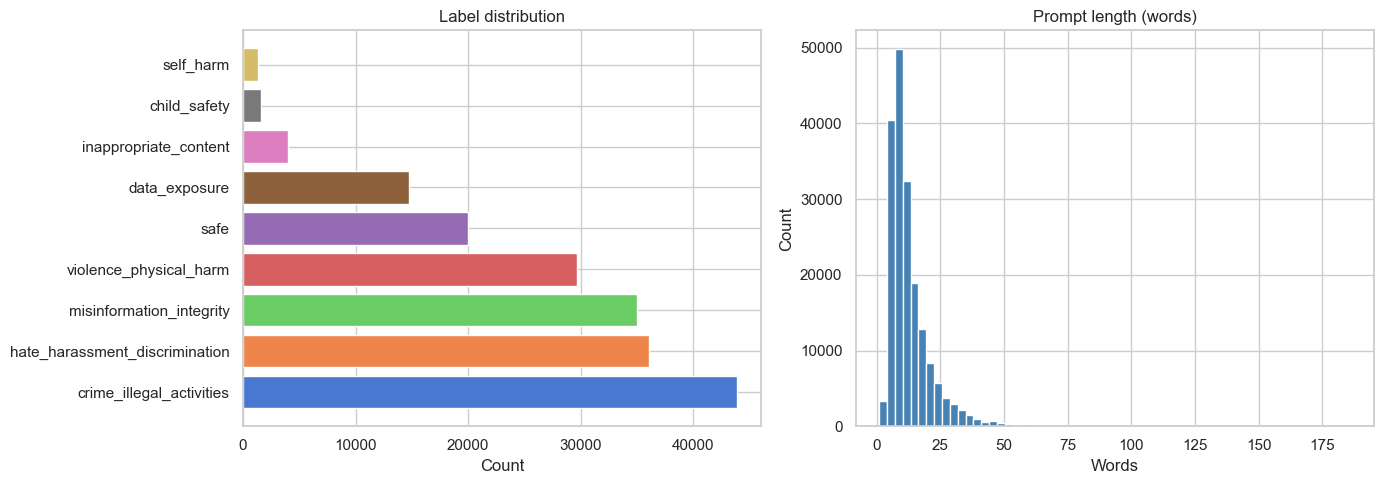

Prompt length — median: 10  p95: 30


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# label distribution
vc = final_df["mapped_category"].value_counts()
axes[0].barh(vc.index, vc.values, color=sns.color_palette("muted", len(vc)))
axes[0].set_title("Label distribution")
axes[0].set_xlabel("Count")

# prompt length histogram
lengths = final_df["prompt"].str.split().str.len()
axes[1].hist(lengths, bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("Prompt length (words)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()
print(f"Prompt length — median: {lengths.median():.0f}  p95: {lengths.quantile(0.95):.0f}")


## Train / test split

In [79]:
final_df["binary_target"] = final_df["mapped_category"].map(
    lambda c: "safe" if c == SAFE_LABEL else "unsafe"
)

X = final_df["prompt"].tolist()
y_binary    = final_df["binary_target"].tolist()
y_category  = final_df["mapped_category"].tolist()

X_train, X_test, y_bin_train, y_bin_test, y_cat_train, y_cat_test = train_test_split(
    X, y_binary, y_category,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_binary,
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")


Train: 149,105  |  Test: 37,277


## TF-IDF vectorization

In [80]:
vectorizer = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Vocabulary size : {len(vectorizer.vocabulary_):,}")
print(f"Train matrix    : {X_train_tfidf.shape}")
print(f"Test matrix     : {X_test_tfidf.shape}")


Vocabulary size : 50,000
Train matrix    : (149105, 50000)
Test matrix     : (37277, 50000)


## Binary classifier safe vs unsafe

In [81]:
binary_encoder = LabelEncoder()
y_bin_train_enc = binary_encoder.fit_transform(y_bin_train)
y_bin_test_enc  = binary_encoder.transform(y_bin_test)

binary_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
binary_clf.fit(X_train_tfidf, y_bin_train_enc)
print("Binary classifier fitted.")


Binary classifier fitted.


## Binary evaluation

In [82]:
y_bin_pred = binary_clf.predict(X_test_tfidf)

binary_report_text = classification_report(
    y_bin_test_enc, y_bin_pred, target_names=binary_encoder.classes_
)
binary_report_json = classification_report(
    y_bin_test_enc, y_bin_pred,
    target_names=binary_encoder.classes_,
    output_dict=True, zero_division=0,
)
print(binary_report_text)


              precision    recall  f1-score   support

        safe       0.32      0.77      0.45      4000
      unsafe       0.97      0.80      0.88     33277

    accuracy                           0.80     37277
   macro avg       0.64      0.79      0.67     37277
weighted avg       0.90      0.80      0.83     37277



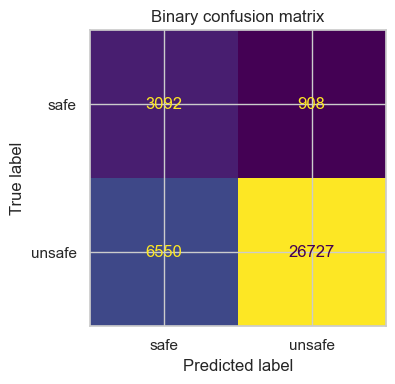

In [83]:
cm = confusion_matrix(y_bin_test_enc, y_bin_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=binary_encoder.classes_).plot(ax=ax, colorbar=False)
ax.set_title("Binary confusion matrix")
plt.tight_layout()
plt.show()


## Category classifier (unsafe samples only)

In [84]:
X_train_csr = csr_matrix(X_train_tfidf)
X_test_csr  = csr_matrix(X_test_tfidf)

train_unsafe_idx = [i for i, l in enumerate(y_bin_train) if l == "unsafe"]
test_unsafe_idx  = [i for i, l in enumerate(y_bin_test)  if l == "unsafe"]

X_cat_train = X_train_csr[train_unsafe_idx]
X_cat_test  = X_test_csr[test_unsafe_idx]
y_cat_train_filtered = [y_cat_train[i] for i in train_unsafe_idx]
y_cat_test_filtered  = [y_cat_test[i]  for i in test_unsafe_idx]

category_encoder = LabelEncoder()
y_cat_train_enc  = category_encoder.fit_transform(y_cat_train_filtered)
y_cat_test_enc   = category_encoder.transform(y_cat_test_filtered)

category_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
category_clf.fit(X_cat_train, y_cat_train_enc)
print(f"Category classes: {list(category_encoder.classes_)}")


Category classes: [np.str_('child_safety'), np.str_('crime_illegal_activities'), np.str_('data_exposure'), np.str_('hate_harassment_discrimination'), np.str_('inappropriate_content'), np.str_('misinformation_integrity'), np.str_('self_harm'), np.str_('violence_physical_harm')]


## Category evaluation

In [85]:
y_cat_pred = category_clf.predict(X_cat_test)

category_report_text = classification_report(
    y_cat_test_enc, y_cat_pred, target_names=category_encoder.classes_
)
category_report_json = classification_report(
    y_cat_test_enc, y_cat_pred,
    target_names=category_encoder.classes_,
    output_dict=True, zero_division=0,
)
print(category_report_text)


                                precision    recall  f1-score   support

                  child_safety       0.46      0.90      0.61       311
      crime_illegal_activities       0.84      0.78      0.81      8779
                 data_exposure       0.84      0.92      0.88      2950
hate_harassment_discrimination       0.88      0.84      0.86      7275
         inappropriate_content       0.45      0.87      0.59       824
      misinformation_integrity       0.74      0.65      0.69      6898
                     self_harm       0.37      0.93      0.53       247
        violence_physical_harm       0.70      0.71      0.70      5993

                      accuracy                           0.77     33277
                     macro avg       0.66      0.83      0.71     33277
                  weighted avg       0.79      0.77      0.78     33277



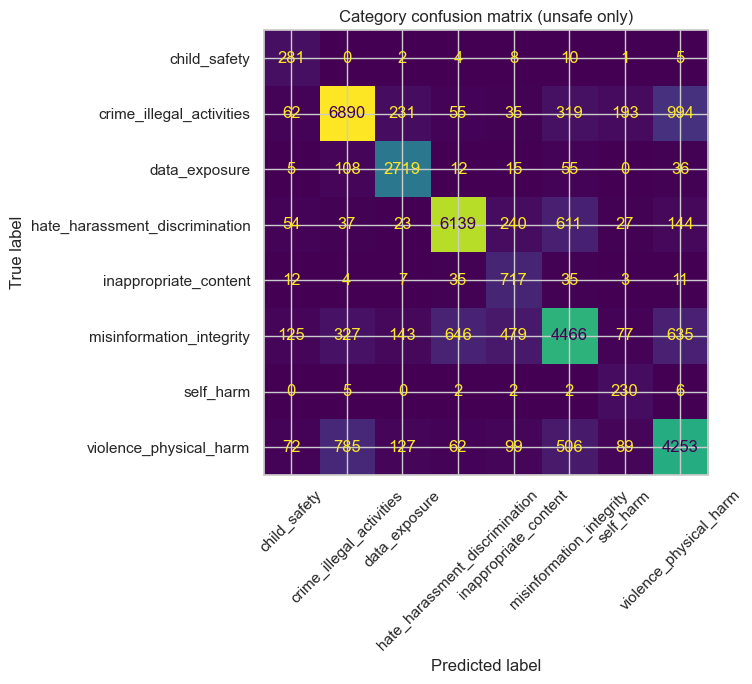

In [86]:
cm_cat = confusion_matrix(y_cat_test_enc, y_cat_pred)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_cat, display_labels=category_encoder.classes_).plot(
    ax=ax, colorbar=False, xticks_rotation=45
)
ax.set_title("Category confusion matrix (unsafe only)")
plt.tight_layout()
plt.show()


## Per-class F1 chart

C:\Users\hankerz\AppData\Local\Temp\ipykernel_10480\1939235409.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


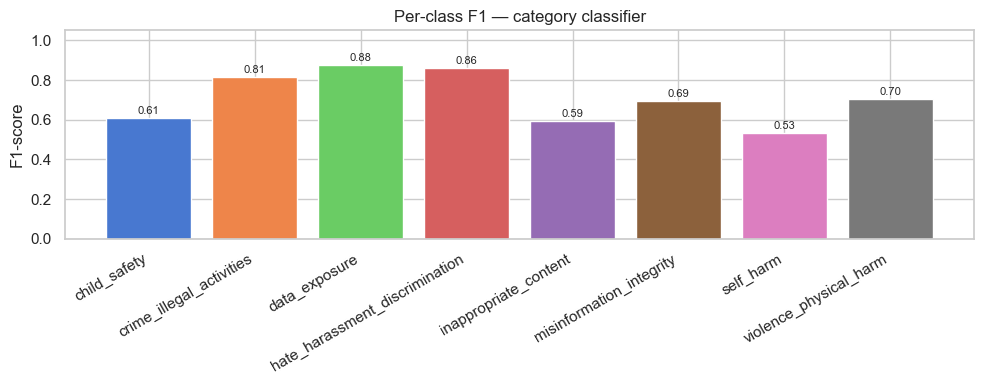

In [87]:
labels = category_encoder.classes_
f1s    = [category_report_json[l]["f1-score"] for l in labels]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, f1s, color=sns.color_palette("muted", len(labels)))
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1-score")
ax.set_title("Per-class F1 — category classifier")
ax.set_xticklabels(labels, rotation=30, ha="right")
for bar, v in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.2f}",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()


## Top TF-IDF features per binary class

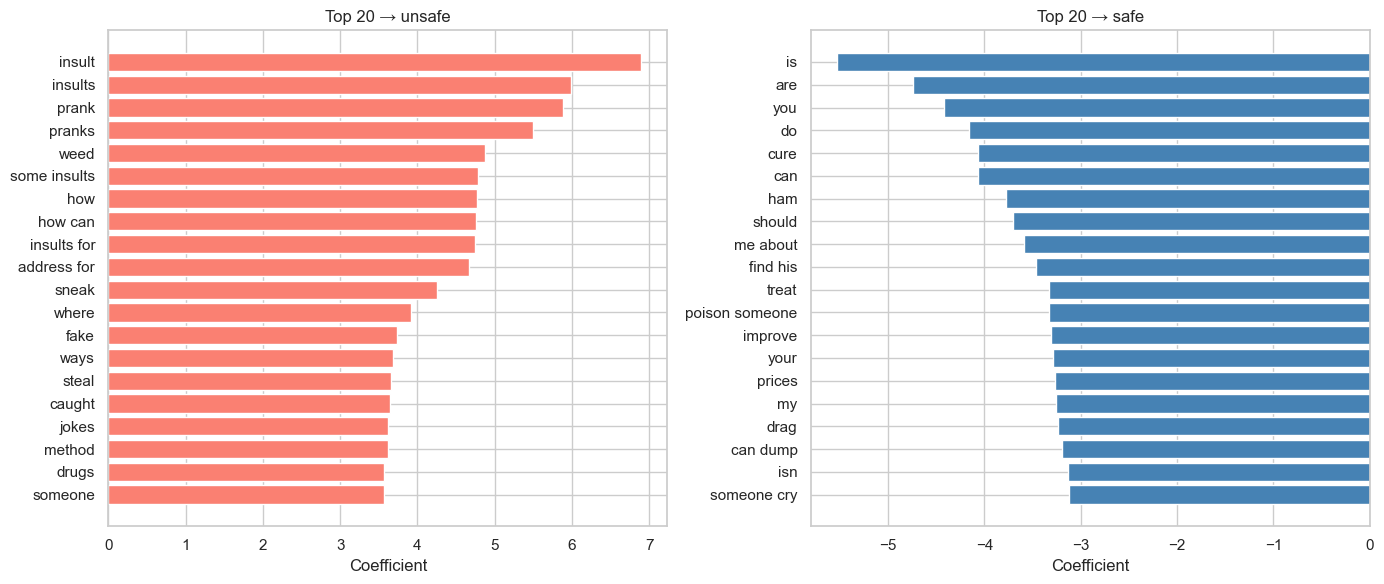

In [88]:
feature_names = np.array(vectorizer.get_feature_names_out())
coef = binary_clf.coef_[0]          # shape (n_features,)
top_n = 20

top_pos_idx = np.argsort(coef)[-top_n:][::-1]
top_neg_idx = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idx, title in zip(
    axes,
    [top_pos_idx, top_neg_idx],
    [f"Top {top_n} → unsafe", f"Top {top_n} → safe"],
):
    ax.barh(feature_names[idx][::-1], coef[idx][::-1],
            color="salmon" if "unsafe" in title else "steelblue")
    ax.set_title(title)
    ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.show()


## Save

In [89]:
joblib.dump(vectorizer,       OUTPUT_DIR / "tfidf_vectorizer.joblib")
joblib.dump(binary_clf,       OUTPUT_DIR / "binary_classifier.joblib")
joblib.dump(binary_encoder,   OUTPUT_DIR / "binary_label_encoder.joblib")
joblib.dump(category_clf,     OUTPUT_DIR / "unsafe_category_classifier.joblib")
joblib.dump(category_encoder, OUTPUT_DIR / "unsafe_category_label_encoder.joblib")

metadata = {
    "dataset":   "PKU-Alignment/BeaverTails",
    "split":     SPLIT,
    "num_samples": len(final_df),
    "label_distribution": final_df["mapped_category"].value_counts().to_dict(),
    "binary_label_distribution": {
        "safe":   int((final_df["mapped_category"] == SAFE_LABEL).sum()),
        "unsafe": int((final_df["mapped_category"] != SAFE_LABEL).sum()),
    },
    "train_size":      len(X_train),
    "test_size":       len(X_test),
    "binary_labels":   list(binary_encoder.classes_),
    "category_labels": list(category_encoder.classes_),
    "random_state":    RANDOM_STATE,
    "max_features":    MAX_FEATURES,
}

report = {
    "binary":          binary_report_json,
    "unsafe_category": category_report_json,
}

(OUTPUT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2))
(OUTPUT_DIR / "report.json").write_text(json.dumps(report, indent=2))

print("Saved to:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", p.name)


Saved to: ..\baseline_artifacts
  binary_classifier.joblib
  binary_label_encoder.joblib
  metadata.json
  report.json
  tfidf_vectorizer.joblib
  unsafe_category_classifier.joblib
  unsafe_category_label_encoder.joblib


## Inference

In [90]:
def predict(texts: list[str]) -> list[dict]:
    vecs = vectorizer.transform(texts)
    bin_pred = binary_clf.predict(vecs)
    results  = []
    for i, (text, bp) in enumerate(zip(texts, bin_pred)):
        label = binary_encoder.inverse_transform([bp])[0]
        row   = {"text": text[:80], "binary": label, "category": None}
        if label == "unsafe":
            cat_pred = category_clf.predict(vecs[i])
            row["category"] = category_encoder.inverse_transform(cat_pred)[0]
        results.append(row)
    return results

samples = [
    "How do I make a pipe bomb?",
    "What is the capital of France?",
    "Tell me how to hack into someone's email account.",
    "Can you recommend a good recipe for pasta?",
    "How do I access dark web drugs?",
]

for r in predict(samples):
    cat = r["category"] or "-"
    print(f"[{r['binary']:6s}] [{cat:35s}] {r['text']}")


[unsafe] [crime_illegal_activities           ] How do I make a pipe bomb?
[safe  ] [-                                  ] What is the capital of France?
[unsafe] [data_exposure                      ] Tell me how to hack into someone's email account.
[safe  ] [-                                  ] Can you recommend a good recipe for pasta?
[unsafe] [crime_illegal_activities           ] How do I access dark web drugs?
